In [131]:
'''
in part 1 we did probability based approach and neural networks with similar perf
predictions were bad bc we only took one char of context

if we take 2 chars we have 27*27 rows in the matrix and if we take 3, it's 27^3 (~20k) 
that's too many rows in the matrix and too few counts for the probability based model to work well
So, we will implement MLP (multi layer perceptron)
follows Bengio et al but we do char level model
'''

"\nin part 1 we did probability based approach and neural networks with similar perf\npredictions were bad bc we only took one char of context\n\nif we take 2 chars we have 27*27 rows in the matrix and if we take 3, it's 27^3 (~20k) \nthat's too many rows in the matrix and too few counts for the probability based model to work well\nSo, we will implement MLP (multi layer perceptron)\nfollows Bengio et al but we do char level model\n"

In [132]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [133]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [134]:
len(words)

32033

In [135]:
# build the vocabulary of characters and mappings to/from integers
# same as makemore1 basically
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [136]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words[:5]: # only doing 5 now
  
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)
# Basically for "emma" we would have ...->e, ..e->m, .em->m, emm->a, mma->.
X.shape, Y.shape

(torch.Size([32, 3]), torch.Size([32]))

In [137]:
# build embedding lookup table from 27 chars into N-D space where N = 2
C = torch.randn((27,2)) # 27 chars * 2D space
C

tensor([[-2.1953e-01, -1.0572e+00],
        [ 4.4988e-02, -4.8665e-01],
        [-3.1402e-01, -5.5478e-01],
        [ 8.2722e-01, -1.3240e+00],
        [-1.7982e+00, -6.8584e-01],
        [ 5.3821e-01, -9.8162e-01],
        [ 6.5598e-01,  9.3655e-02],
        [-5.6192e-01,  7.5639e-01],
        [-1.3123e+00,  4.0247e-02],
        [ 1.7303e+00, -5.6011e-01],
        [ 8.2250e-01,  4.4285e-01],
        [-1.1589e+00,  2.5096e+00],
        [ 3.9877e-01, -8.4426e-01],
        [-1.0097e+00,  6.1711e-01],
        [ 1.5716e-01,  1.6240e+00],
        [ 2.8249e+00, -3.2001e-01],
        [ 3.3382e-01, -5.6718e-01],
        [ 1.5447e-01, -1.0650e+00],
        [ 1.4756e+00,  3.0026e-01],
        [-3.1049e-01, -1.8454e+00],
        [ 8.4244e-01, -1.2524e-02],
        [ 7.3715e-01,  3.8011e-01],
        [ 1.2246e+00,  6.2170e-04],
        [ 6.4237e-01,  3.8473e-01],
        [ 1.5368e+00, -5.5897e-02],
        [ 9.5890e-01, -1.0176e+00],
        [ 4.4446e-01, -1.0695e+00]])

In [138]:
# get the embedding of letter 5 for example
C[5]

tensor([ 0.5382, -0.9816])

In [139]:
# or use one-hot encodings:
F.one_hot(torch.tensor([5]), num_classes=27).float() @ C

tensor([[ 0.5382, -0.9816]])

In [140]:
# we get the same val as above, we'll do direct lookup here bc we can index multiple items
C[torch.tensor([5,6,7])]

tensor([[ 0.5382, -0.9816],
        [ 0.6560,  0.0937],
        [-0.5619,  0.7564]])

In [141]:
# even for multi dimensional vectors :O
C[X]

tensor([[[-2.1953e-01, -1.0572e+00],
         [-2.1953e-01, -1.0572e+00],
         [-2.1953e-01, -1.0572e+00]],

        [[-2.1953e-01, -1.0572e+00],
         [-2.1953e-01, -1.0572e+00],
         [ 5.3821e-01, -9.8162e-01]],

        [[-2.1953e-01, -1.0572e+00],
         [ 5.3821e-01, -9.8162e-01],
         [-1.0097e+00,  6.1711e-01]],

        [[ 5.3821e-01, -9.8162e-01],
         [-1.0097e+00,  6.1711e-01],
         [-1.0097e+00,  6.1711e-01]],

        [[-1.0097e+00,  6.1711e-01],
         [-1.0097e+00,  6.1711e-01],
         [ 4.4988e-02, -4.8665e-01]],

        [[-2.1953e-01, -1.0572e+00],
         [-2.1953e-01, -1.0572e+00],
         [-2.1953e-01, -1.0572e+00]],

        [[-2.1953e-01, -1.0572e+00],
         [-2.1953e-01, -1.0572e+00],
         [ 2.8249e+00, -3.2001e-01]],

        [[-2.1953e-01, -1.0572e+00],
         [ 2.8249e+00, -3.2001e-01],
         [ 3.9877e-01, -8.4426e-01]],

        [[ 2.8249e+00, -3.2001e-01],
         [ 3.9877e-01, -8.4426e-01],
         [ 1.7303e+00,

In [142]:
emb = C[X] # embedding
emb.shape # 32, 3, 2 (for each of the 32 items in the training set we have 3 items of context and 2 items of embedding for each)

torch.Size([32, 3, 2])

In [143]:
# construct hidden layer
W1 = torch.randn((6, 100)) # 100 neurons in the hidden layer, 6 because we stack 3(context)*2(embedding len) here 
b1 = torch.randn(100)

# can't multiply emb @ W because of the dimensions. We need to flatten the 3*2

In [144]:
torch.cat(torch.unbind(emb, 1), 1).shape # flattens into 32,6 manually

torch.Size([32, 6])

In [145]:
# but actually we can use Tensor.view, very efficient because no changes to underlying storage
emb = emb.view(emb.shape[0], 6) # can also pass -1 instead of emb.shape[0] and let torch infer the dimension
emb.shape

torch.Size([32, 6])

In [146]:
# so, hidden layer is:
h = torch.tanh(emb @ W1 + b1) # read broadcasting semantics for the addition
h.shape # 100 output neurons for the 32 input examples

torch.Size([32, 100])

In [147]:
# Final layer
W2 = torch.randn((100, 27)) # 100 hidden neurons -> 27 output logits
b2 = torch.randn(27)
logits = h @ W2 + b2
logits.shape # 32, 27 -> 32 items in training set -> 27 logits each

torch.Size([32, 27])

In [148]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
prob.shape

torch.Size([32, 27])

In [149]:
# now we need to get the loss by getting prob assigned to correct char
prob[torch.arange(32)] # iterate through rows with arange

tensor([[1.1886e-06, 6.6845e-11, 1.1237e-11, 7.2205e-12, 1.2533e-16, 8.5464e-14,
         3.8553e-09, 6.6112e-07, 1.1278e-11, 5.2847e-18, 1.7295e-10, 5.3691e-09,
         1.0408e-07, 1.5200e-09, 2.0214e-21, 2.4429e-12, 2.1901e-13, 9.9996e-01,
         2.7943e-11, 1.2607e-17, 1.5253e-11, 1.8996e-15, 5.0006e-08, 9.3951e-11,
         6.0032e-14, 7.4498e-08, 4.1986e-05],
        [7.1931e-05, 1.1886e-07, 3.2198e-09, 3.0440e-05, 7.1446e-13, 4.7328e-10,
         4.4354e-04, 7.3879e-05, 1.6326e-09, 9.5870e-14, 6.3005e-06, 7.1443e-05,
         5.6785e-01, 1.7678e-06, 2.5169e-15, 8.9840e-09, 2.1762e-12, 4.3144e-01,
         3.5522e-06, 9.6263e-12, 9.9674e-09, 6.1698e-12, 2.7592e-08, 3.3662e-07,
         5.1156e-08, 6.6569e-06, 2.9038e-06],
        [9.7576e-01, 1.1629e-16, 2.8767e-14, 2.5542e-17, 2.3853e-11, 3.6124e-15,
         7.0638e-14, 3.3538e-06, 3.6294e-14, 5.7448e-16, 1.2035e-07, 5.4993e-09,
         2.9248e-10, 1.5602e-08, 7.0375e-17, 2.7550e-18, 1.0501e-13, 9.3080e-03,
         1.7109e-

In [150]:
prob[torch.arange(32), Y] # probability assigned to Y by this model

tensor([8.5464e-14, 1.7678e-06, 1.5602e-08, 6.4162e-13, 2.3743e-18, 2.4429e-12,
        4.3703e-01, 6.2534e-14, 1.9162e-05, 1.2448e-12, 1.0886e-10, 2.3493e-05,
        6.6845e-11, 2.6606e-08, 2.8352e-10, 8.4337e-08, 5.2847e-18, 4.2299e-13,
        1.7080e-09, 2.6965e-07, 2.1405e-12, 8.4585e-01, 8.4694e-01, 1.1626e-11,
        3.3435e-04, 1.2607e-17, 6.3606e-07, 5.6478e-20, 4.3579e-13, 4.8706e-15,
        4.5067e-07, 3.4008e-08])

In [151]:
nll = -prob[torch.arange(32), Y].log().mean()
nll

tensor(21.6767)

In [152]:
# the logits -> count -> NLL is common enough that torch has F.cross_entropy
nll = F.cross_entropy(logits, Y) # more efficient and much easier to do backward pass
# also, we can't pass large logits becuase exp step is e^n which overflows float
# torch internally calculates max value of logits and subtracts all items in the tensor by that
# the result is still the same because we divide by sum
# TLDR use torch stuff when you can instead of rolling your own
nll # same as above exactly

tensor(21.6767)

In [153]:
# rewriting code above

In [173]:
# setup model weights
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters: p.requires_grad = True

In [198]:
for _ in range(1000):
    # Fwd pass
    emb = C[X].view(-1, 6)
    h = torch.tanh(emb @ W1 + b1) # read broadcasting semantics for the addition
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y) # more efficient and much easier to do backward pass
    # print(loss)
    
    # Backward pass
    for p in parameters: p.grad = None
    loss.backward()
    
    # update
    for p in parameters: 
        p.data += -0.01 * p.grad
print (loss)

tensor(3.9870, grad_fn=<NllLossBackward0>)


In [215]:
#
# --- Rewrite all together with full dataset. mostly copied from above, with minibatch
#

In [326]:
# 1/ Build dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
embedding_size = 2
X, Y = [], []
for w in words:

  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)
# Basically for "emma" we would have ...->e, ..e->m, .em->m, emm->a, mma->.
X.shape, Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [333]:
# 2/ Init model
g = torch.Generator().manual_seed(2147483647)

# hidden layer
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

# output layer
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

for p in parameters: p.requires_grad = True

In [336]:
# training loop
for _ in range(100):

    # create minibatch
    ix = torch.randint(0, X.shape[0], (32,)) # picks random items in the dataset and we use that to index into X, Y
    
    # Fwd pass
    emb = C[X[ix]].view(-1, 6)
    h = torch.tanh(emb @ W1 + b1) # read broadcasting semantics for the addition
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix]) # more efficient and much easier to do backward pass
    print(loss)
    
    # Backward pass
    for p in parameters: p.grad = None
    loss.backward()
    
    # update
    for p in parameters: 
        p.data += -0.01 * p.grad
print (loss)

tensor(17.8777, grad_fn=<NllLossBackward0>)
tensor(16.7047, grad_fn=<NllLossBackward0>)
tensor(15.1214, grad_fn=<NllLossBackward0>)
tensor(13.2876, grad_fn=<NllLossBackward0>)
tensor(11.6966, grad_fn=<NllLossBackward0>)
tensor(13.1111, grad_fn=<NllLossBackward0>)
tensor(10.6633, grad_fn=<NllLossBackward0>)
tensor(11.0261, grad_fn=<NllLossBackward0>)
tensor(9.8352, grad_fn=<NllLossBackward0>)
tensor(11.0304, grad_fn=<NllLossBackward0>)
tensor(9.1970, grad_fn=<NllLossBackward0>)
tensor(10.6203, grad_fn=<NllLossBackward0>)
tensor(11.3779, grad_fn=<NllLossBackward0>)
tensor(10.2090, grad_fn=<NllLossBackward0>)
tensor(8.2652, grad_fn=<NllLossBackward0>)
tensor(6.8996, grad_fn=<NllLossBackward0>)
tensor(9.5048, grad_fn=<NllLossBackward0>)
tensor(7.2005, grad_fn=<NllLossBackward0>)
tensor(6.5557, grad_fn=<NllLossBackward0>)
tensor(7.8374, grad_fn=<NllLossBackward0>)
tensor(6.0449, grad_fn=<NllLossBackward0>)
tensor(5.9928, grad_fn=<NllLossBackward0>)
tensor(7.1304, grad_fn=<NllLossBackward0>)

In [291]:
'''
since we do minibatches, the quality of each step is moderate but much faster
so we can do many steps
'''

'\nsince we do minibatches, the quality of each step is moderate but much faster\nso we can do many steps\n'

In [323]:
# loss above is only for minibatch, but let's calc loss on entire thing
emb = C[X].view(-1, 6)
h = torch.tanh(emb @ W1 + b1) 
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(2.9320, grad_fn=<NllLossBackward0>)

In [337]:
'''
how do we determine the learning rate though? 
if the step is really small the loss barely increases
at 0.0001 it barely changes
at 1 it goes back and forth so it's too fast
at 10 it doesn't even work lol
so the right learning rate is between 0.0001 and 1
'''

"\nhow do we determine the learning rate though? \nif the step is really small the loss barely increases\nat 0.0001 it barely changes\nat 1 it goes back and forth so it's too fast\nat 10 it doesn't even work lol\nso the right learning rate is between 0.0001 and 1\n"

In [351]:
lre = torch.linspace(-3, 0, 1000) # learning rate exponent
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [406]:
#
# --- Rewrite again with learning rate stuff (same dataset as above tho)
#

In [510]:
# 2/ Init model
g = torch.Generator().manual_seed(2147483647)

# embeddings
C = torch.randn((27, 2), generator=g)

# hidden layer
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

# output layer
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

for p in parameters: p.requires_grad = True

In [511]:
lre = torch.linspace(-3, 0, 10000) # learning rate exponent
lrs = 10**lre

# stats
lri = [] # learning rate at i
lossi = [] # loss at i

# training loop
for i in range(10000):

    # create minibatch
    ix = torch.randint(0, X.shape[0], (32,)) # picks random items in the dataset and we use that to index into X, Y
    
    # Fwd pass
    emb = C[X[ix]].view(-1, 6)
    h = torch.tanh(emb @ W1 + b1) # read broadcasting semantics for the addition
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix]) # more efficient and much easier to do backward pass
    # print(loss)
    
    # Backward pass
    for p in parameters: p.grad = None
    loss.backward()
    
    # update
    # lr = lrs[i]
    for p in parameters: 
        # we initially use the lrs to find a good learning rate.
        # p.data += -lr * p.grad
        # We determined below that was 0.1. 
        # p.data += -0.1 * p.grad
        # after some iterations we do learning rate decay
        p.data += -0.01 * p.grad

    # stats
    lri.append(lre[i])
    lossi.append(loss.item())
print (loss)

tensor(2.3222, grad_fn=<NllLossBackward0>)


In [512]:
# full loss like above
emb = C[X].view(-1, 6)
h = torch.tanh(emb @ W1 + b1) 
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y)
loss

tensor(2.6827, grad_fn=<NllLossBackward0>)

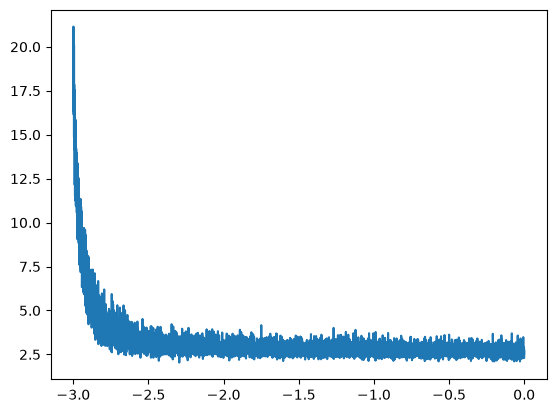

In [513]:
plt.plot(lri, lossi)

In [465]:
# using the graph above, we can see that loss is minimized at lre=-1 aka lr = 0.1

In [466]:
'''
the model right now is pretty small but can get v large (10k, 100k, Ms of params)
as it grows it becomes more capable of overfitting the dataset
loss is low but it just memorizes the dataset
if we evaluate loss on part of dataset that isn't used in training it might be v high

standard approach:
split up dataset into 3:
1/ training 80%: -- used to optimize params of model using gradient descent
2/ validateion/dev 10%  -- used for hyperparmeter tuning
3/ test 10% -- evaluate the model but used sparingly so we don't actually train on the test set
'''


"\nthe model right now is pretty small but can get v large (10k, 100k, Ms of params)\nas it grows it becomes more capable of overfitting the dataset\nloss is low but it just memorizes the dataset\nif we evaluate loss on part of dataset that isn't used in training it might be v high\n\nstandard approach:\nsplit up dataset into 3:\n1/ training 80%: -- used to optimize params of model using gradient descent\n2/ validateion/dev 10%  -- used for hyperparmeter tuning\n3/ test 10% -- evaluate the model but used sparingly so we don't actually train on the test set\n"

In [541]:
# build the dataset with splits
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182512, 3]) torch.Size([182512])
torch.Size([22860, 3]) torch.Size([22860])
torch.Size([22774, 3]) torch.Size([22774])


In [551]:
# 2/ Init model
g = torch.Generator().manual_seed(2147483647)

# embeddings
C = torch.randn((27, 10), generator=g)

# hidden layer
W1 = torch.randn((30, 200))
b1 = torch.randn(200)

# output layer
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

for p in parameters: p.requires_grad = True
sum(p.nelement() for p in parameters)

11897

In [552]:
# stats
lri = [] # learning rate at i
lossi = [] # loss at i
stepi = []

In [580]:
# lre = torch.linspace(-3, 0, 10000) # learning rate exponent
# lrs = 10**lre

# training loop
for i in range(30000):

    # create minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,)) # picks random items in the dataset and we use that to index into X, Y
    
    # Fwd pass
    emb = C[Xtr[ix]].view(-1, 30)
    h = torch.tanh(emb @ W1 + b1) # read broadcasting semantics for the addition
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix]) # more efficient and much easier to do backward pass
    # print(loss)
    
    # Backward pass
    for p in parameters: p.grad = None
    loss.backward()
    
    # update
    # lr = lrs[i]
    for p in parameters: 
        # we initially use the lrs to find a good learning rate.
        # p.data += -lr * p.grad
        # We determined below that was 0.1. 
        # p.data += -0.1 * p.grad
        # after some iterations we do learning rate decay
        p.data += -0.01 * p.grad

    # stats
    # lri.append(lre[i])
    lossi.append(loss.log10().item()) # use log to remove the hockey stick appearance
    stepi.append(i)
print (loss)

tensor(2.2355, grad_fn=<NllLossBackward0>)


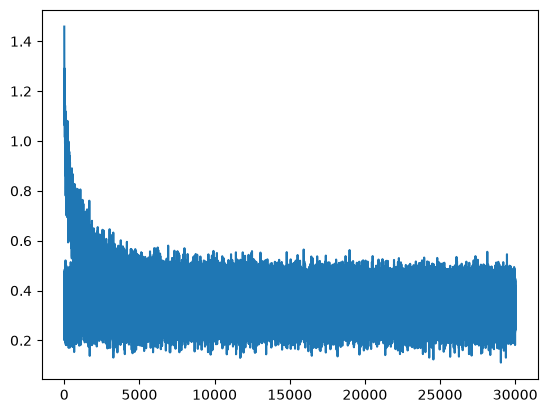

In [581]:
plt.plot(stepi, lossi)

In [582]:
# trainig loss full loss like above but only on dev set
emb = C[Xtr].view(-1, 30)
h = torch.tanh(emb @ W1 + b1) 
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0991, grad_fn=<NllLossBackward0>)

In [583]:
# dev loss: full loss like above but only on dev set
emb = C[Xdev].view(-1, 30)
h = torch.tanh(emb @ W1 + b1) 
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1446, grad_fn=<NllLossBackward0>)

In [578]:
# This model can't overfit bc it's small. Let's make it bigger (inline)
# see the graph above. it goes up and down bc the minibatch is so small
# we can increase the batch size (inline)
# model still isn't great. 2D embedding space is small, we can increase to 10
# we're doing things quite haphazardly here. In production you'd keep a set of hyperparams and run experiments on them 
# Experiments use dev set and then you report test set loss in papers etc

In [584]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carlah.
amorie.
khi.
miliataly.
skansh.
eja.
hube.
deviah.
jareei.
nellara.
chaiiy.
kaleigh.
ham.
jord.
quint.
suline.
liveni.
wazelo.
dearynix.
kael.


In [585]:
# ^ names here are much better! 